# Interaction Store

Persistent INDRA-based curation of gene interactions for exploratory mechanistic research.

**Colour scheme**
- 🔵 Autosomal genes
- 🔴 X-linked genes  
- 🟡 Y-linked genes
- ⚪ Signalling intermediates

**Edge types**
- `Activation` — promotes / upregulates
- `Inhibition` — antagonises / suppresses
- `Phosphorylation` — direct phosphorylation event
- `Complex` — physical association without clear directionality
- `Conversion` — enzymatic conversion of a substrate

---

In [ ]:
# ── dependencies ──────────────────────────────────────────────────────────────
# pixi add indra graph-tool matplotlib

import json
import pathlib
from datetime import date

import graph_tool.all as gt
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from indra.statements import (
    Agent, Evidence,
    Activation, Inhibition, Phosphorylation,
    Complex, Conversion, DecreaseAmount, IncreaseAmount,
    stmts_to_json, stmts_from_json,
)
from gene_registry import (
    get_gene_info, get_all_groups, get_all_contexts,                
    genes_by_context, genes_by_group, get_interactors,
    query_statements, query_registry,
)
                                        

STORE_PATH = pathlib.Path('statements.json')

from vscodenb import set_vscode_theme
set_vscode_theme()

## Store helpers

In [2]:
def load_store(path=STORE_PATH):
    """Load statements from JSON file, return list of INDRA Statement objects."""
    if not path.exists():
        return []
    with open(path) as f:
        return stmts_from_json(json.load(f))


def save_store(stmts, path=STORE_PATH):
    """Serialise statement list to JSON file."""
    with open(path, 'w') as f:
        json.dump(stmts_to_json(stmts), f, indent=2)
    print(f'Saved {len(stmts)} statements → {path}')


def add_statements(new_stmts, path=STORE_PATH):
    """Append new statements to the persistent store."""
    existing = load_store(path)
    combined = existing + new_stmts
    save_store(combined, path)
    return combined


def ev(text, pmid=None, doi=None, context=None, hypothesis=False, direct=True):
    """Convenience: create a manual Evidence object.

    Args:
        text:       Mechanistic reasoning or supporting sentence.
        pmid:       PubMed ID string, e.g. '23640493'.
        doi:        DOI string, e.g. '10.1161/ATVBAHA.113.301522'.
        context:    Module name or thematic tag.
        hypothesis: True if this is speculative / not yet confirmed.
        direct:     False if interaction is pathway-level, not protein-protein.
    """
    text_refs = {}
    if pmid: text_refs['PMID'] = str(pmid)
    if doi:  text_refs['DOI']  = doi
    return Evidence(
        text=text,
        source_api='manual',
        pmid=pmid,
        text_refs=text_refs or None,
        annotations={
            'date':       str(date.today()),
            'context':    context or 'exploratory',
            'directness': 'direct' if direct else 'indirect',
        },
        epistemics={'hypothesis': hypothesis},
    )


def ag(name, hgnc=None, up=None):
    """Convenience: create an Agent with optional db_refs."""
    db_refs = {}
    if hgnc:
        db_refs['HGNC'] = str(hgnc)
    if up:
        db_refs['UP'] = up
    return Agent(name, db_refs=db_refs or None)


def summarise(path=STORE_PATH):
    """Print a readable summary of the store."""
    stmts = load_store(path)
    print(f'{len(stmts)} statements in store\n')
    by_type = {}
    for s in stmts:
        t = type(s).__name__
        by_type.setdefault(t, []).append(s)
    for t, ss in sorted(by_type.items()):
        print(f'  {t}: {len(ss)}')
    print()
    for s in stmts:
        subj = s.agent_list()[0].name if s.agent_list() else '?'
        obj  = s.agent_list()[-1].name if len(s.agent_list()) > 1 else ''
        txt  = s.evidence[0].text[:70] if s.evidence else ''
        print(f'  [{type(s).__name__:20s}]  {subj:12s} → {obj:12s}  "{txt}"')


print('helpers ok')

helpers ok


## Seed statements

All interactions identified in the exploratory session (March 2026).
Run once — subsequent runs will append duplicates, so guard with the
`if not STORE_PATH.exists()` check.

In [3]:
if not STORE_PATH.exists():

    seed_stmts = [

        # ── cAMP / PKA module ────────────────────────────────────────────────
        Inhibition(
            ag('ADRA2C'), ag('ADCY'),   # adenylyl cyclase
            evidence=[ev(
                'ADRA2C couples to Gi, suppresses adenylyl cyclase, '
                'reducing intracellular cAMP',
                context='cAMP/PKA module'
            )]
        ),
        Activation(
            ag('ADCY'), ag('cAMP'),
            evidence=[ev('Adenylyl cyclase catalyses ATP→cAMP', context='cAMP/PKA module')]
        ),
        Activation(
            ag('cAMP'), ag('PKA'),
            evidence=[ev(
                'cAMP binds PKA regulatory subunits, releasing and activating '
                'catalytic subunits PRKACA/B',
                context='cAMP/PKA module'
            )]
        ),
        Activation(
            ag('cAMP'), ag('PRKX'),   # X-linked PKA paralog
            evidence=[ev(
                'PRKX is a cAMP-dependent protein kinase catalytic subunit '
                'at Xp22.3; activated by cAMP analogously to PRKACA',
                context='cAMP/PKA module — X-linked'
            )]
        ),
        Activation(
            ag('cAMP'), ag('PRKY'),   # Y-linked PKA paralog
            evidence=[ev(
                'PRKY is the Y-linked paralog of PRKX; expression is '
                'downregulated ~0.64-fold in haplogroup I carriers '
                '(Eales et al. 2019 Arterioscler Thromb Vasc Biol)',
                context='cAMP/PKA module — Y-linked'
            )]
        ),
        Activation(
            ag('PJA1'), ag('PKA'),    # X-linked E3 ligase
            evidence=[ev(
                'PJA1 (X-linked RING E3 ligase) ubiquitinates PRKAR1A/2A for '
                'proteasomal degradation, depleting the inhibitory R-subunit '
                'pool and amplifying free catalytic PKA activity. '
                'Opposes ADRA2C suppression of cAMP at the PKA level.',
                context='cAMP/PKA module — rescue candidate'
            )]
        ),
        Complex(
            [ag('AKAP4'), ag('PKA')],  # X-linked scaffold
            evidence=[ev(
                'AKAP4 scaffolds PKA R/C subunits to the fibrous sheath '
                'in spermatids; localises PKA without altering its activation '
                'state',
                context='cAMP/PKA module — structural'
            )]
        ),
        Phosphorylation(
            ag('PKA'), ag('MAPT'),
            evidence=[ev(
                'PKA phosphorylates tau (MAPT) at multiple sites including '
                'Ser214, Thr231; overlapping sites also targeted by PRKX/PRKY',
                context='cAMP/PKA → tau → MT lattice'
            )]
        ),

        # ── IRS2 / PI3K / Akt module ────────────────────────────────────────
        Activation(
            ag('IRS2'), ag('AKT1'),
            evidence=[ev(
                'IRS2 docks to insulin/IGF receptor, recruits PI3K, '
                'generating PIP3 which recruits and activates Akt',
                context='IRS2/PI3K/Akt module'
            )]
        ),
        Inhibition(
            ag('AKT1'), ag('GSK3B'),
            evidence=[ev(
                'Akt phosphorylates GSK3β at Ser9, causing inhibitory '
                'autoinhibition; reduces GSK3β-dependent tau phosphorylation',
                context='IRS2/PI3K/Akt → GSK3β → tau'
            )]
        ),
        Phosphorylation(
            ag('GSK3B'), ag('MAPT'),
            evidence=[ev(
                'GSK3β is a principal tau kinase; phosphorylates multiple '
                'epitopes including Thr231, Ser396. Hyperphosphorylated tau '
                'detaches from MTs, reducing lattice occupancy for motor '
                'competition',
                context='GSK3β → tau → MT lattice'
            )]
        ),
        Inhibition(
            ag('AKT1'), ag('HDAC6'),  # X-linked deacetylase
            evidence=[ev(
                'Akt phosphorylates HDAC6 at Ser22, inhibiting its '
                'α-tubulin Lys40 deacetylase activity. Acetylated tubulin '
                'is the preferred track for kinesin-1 (KIF5B) and dynein. '
                'IRS2 → Akt thus promotes selective MT-based transport via '
                'X-linked HDAC6',
                context='IRS2/Akt → HDAC6 — X-linked effector, direct rescue candidate'
            )]
        ),
        Inhibition(
            ag('TPTE'), ag('PIP3'),   # PTEN paralog, autosomal
            evidence=[ev(
                'TPTE is a PTEN paralog with PI(3,4,5)P3 3-phosphatase '
                'activity; dephosphorylates PIP3, opposing IRS2→PI3K. '
                'Tissue-restricted (testis)',
                context='TPTE/OCRL phosphoinositide triangle'
            )]
        ),
        Inhibition(
            ag('OCRL'), ag('PIP2'),   # X-linked Lowe syndrome gene
            evidence=[ev(
                'OCRL (X-linked) is a PI(4,5)P2 5-phosphatase; depletes '
                'PI(4,5)P2 at endosomes. Adjacent phosphoinositide pool to '
                'PIP3 regulated by TPTE and IRS2. Functional triangle but '
                'distinct lipid species — not directly rescuable across genes',
                context='TPTE/OCRL phosphoinositide triangle'
            )]
        ),

        # ── MT lattice / transport module ────────────────────────────────────
        Inhibition(
            ag('MAPT'), ag('MT_lattice'),
            evidence=[ev(
                'Phosphorylated tau dissociates from MTs, reducing MT lattice '
                'occupancy. Hypophosphorylated tau competes with MAP7D3 and '
                'kinesin-1 for binding sites',
                context='tau → MT occupancy competition'
            )]
        ),
        Activation(
            ag('MAP7D3'), ag('MT_lattice'),   # X-linked kinesin activator
            evidence=[ev(
                'MAP7D3 (Xq26.1) binds MT lattice, recruits KIF5 (kinesin-1) '
                'for anterograde transport. Competes with tau for overlapping '
                'binding sites. IRS2→GSK3β→tau axis sets available MAP7D3 '
                'binding surface',
                context='MAP7D3 / tau competition — indirect rescue candidate'
            )]
        ),
        Inhibition(
            ag('HDAC6'), ag('MT_lattice'),
            evidence=[ev(
                'HDAC6 deacetylates α-tubulin Lys40, reducing acetylated MT '
                'track available for kinesin-1 and dynein processivity',
                context='HDAC6 → MT acetylation → motor preference'
            )]
        ),

        # ── Neurotrophin / endosome module ───────────────────────────────────
        Inhibition(
            ag('SORCS3'), ag('TrkB_endosome'),
            evidence=[ev(
                'SORCS3 (VPS10-domain receptor) gates TrkB sorting to late '
                'endosomes after BDNF binding; controls cargo identity of '
                'retrograde signalling endosomes on axonal MTs',
                context='Neurotrophin retrograde transport'
            )]
        ),
        Activation(
            ag('DYNLT3'), ag('TrkB_endosome'),  # X-linked dynein light chain
            evidence=[ev(
                'DYNLT3 (Tctex-type dynein light chain, X-linked) is '
                'incorporated into cytoplasmic dynein-1 complex; required '
                'for retrograde transport of TrkB-containing endosomes. '
                'Cargo specification (SORCS3) and motor subunit '
                '(DYNLT3) are adjacent steps — not rescuable',
                context='Neurotrophin retrograde transport — X-linked motor'
            )]
        ),
        Activation(
            ag('BEX2'), ag('TrkB_endosome'),   # X-linked
            evidence=[ev(
                'BEX2 (X-linked) interacts with p75NTR and modulates '
                'BDNF/TrkB co-receptor signalling. Acts at p75NTR/TrkB '
                'co-receptor interface upstream of SORCS3 endosomal sorting. '
                'Different positional logic — not rescuable by SORCS3',
                context='Neurotrophin receptor complex — X-linked'
            )]
        ),

        # ── RNA processing / NMD module ──────────────────────────────────────
        Activation(
            ag('UPF3B'), ag('NMD_fragment'),   # X-linked NMD factor
            evidence=[ev(
                'UPF3B (X-linked) is a core NMD factor; recruits endonuclease '
                'that generates 3′ cleavage fragment from NMD targets',
                context='NMD pathway — sequential with XRN2'
            )]
        ),
        Inhibition(
            ag('XRN2'), ag('NMD_fragment'),
            evidence=[ev(
                'XRN2 (autosomal 5′→3′ exoribonuclease) degrades the 3′ '
                'cleavage fragment generated after UPF3B-mediated cleavage. '
                'Sequential steps: UPF3B generates substrate, XRN2 degrades '
                'it. XRN2 upregulation cannot rescue UPF3B loss — wrong order',
                context='NMD pathway — not rescuable'
            )]
        ),
        Complex(
            [ag('DDX3X'), ag('XRN2')],   # X-linked helicase
            evidence=[ev(
                'DDX3X (X-linked RNA helicase) cooperates with XRN2 and '
                'RBMX2 in mRNA biogenesis; co-precipitated in splicing '
                'regulatory complexes',
                context='RNA processing cluster'
            )]
        ),
        IncreaseAmount(
            ag('RBMX2'), ag('RBMX'),    # MSCI paralog backup
            evidence=[ev(
                'RBMX2 (autosomal chr22) is a retroposed paralog of RBMX '
                '(Xq26.3); serves as backup during MSCI when RBMX is silenced. '
                'Both regulate MAPT exon 10 alternative splicing (3R/4R ratio). '
                'This is a paralog-compensation model, not direct rescue by '
                'altered expression',
                context='MSCI compensation — paralog backup'
            )]
        ),

        # ── Centriolar module ────────────────────────────────────────────────
        Complex(
            [ag('OFD1'), ag('SPATC1')],  # OFD1 X-linked; SPATC1 autosomal
            evidence=[ev(
                'OFD1 (X-linked) controls centriole length and CP110 removal '
                'for ciliogenesis; SPATC1 (autosomal) localises to centrioles '
                'during spermiogenesis for manchette attachment. '
                'Co-occupancy of organelle — not biochemical rescue',
                context='Centriolar/manchette module — structural'
            )]
        ),

        # ── NF-κB module ─────────────────────────────────────────────────────
        Activation(
            ag('EDA'), ag('NFKB1'),    # EDA X-linked
            evidence=[ev(
                'EDA (X-linked ectodysplasin) signals via EDAR → TRAF6 → IKK '
                '→ NF-κB; activates κB-dependent transcriptional programme',
                context='NF-κB module'
            )]
        ),
        Activation(
            ag('NFKB1'), ag('HIVEP3'),
            evidence=[ev(
                'HIVEP3 binds κB enhancer elements; acts downstream of NF-κB '
                'activation driven by EDA/EDAR signalling. Losing EDA signal '
                'collapses upstream input; HIVEP3 upregulation cannot rescue',
                context='NF-κB module — not rescuable'
            )]
        ),

        # ── ADRA2C / PJA1 convergence on PKA (rescue candidate) ──────────────
        # (main rescue logic: ADRA2C↓cAMP→PKA↓; PJA1↑degrades R-subunits→PKA↑)
        # Already encoded above; add an explicit Inhibition ADRA2C→PKA for clarity
        Inhibition(
            ag('ADRA2C'), ag('PKA'),
            evidence=[ev(
                'Net effect: ADRA2C suppresses PKA activity via cAMP reduction. '
                'PJA1 opposes this by depleting inhibitory R-subunits. '
                'Best rescue candidate in the dataset: two rheostat-like inputs '
                'on the same PKA pool via different mechanisms',
                context='ADRA2C/PJA1 rescue candidate — most plausible'
            )]
        ),

    ]

    save_store(seed_stmts)
    print(f'Seeded store with {len(seed_stmts)} statements')

else:
    print('Store already exists — skipping seed. Run summarise() to inspect.')

summarise()

Store already exists — skipping seed. Run summarise() to inspect.
25 statements in store

  Activation: 9
  Complex: 5
  Inhibition: 9
  Phosphorylation: 2

  [Inhibition          ]  ADRA2C       → ADCY          "ADRA2C couples to Gi, suppresses adenylyl cyclase, reducing intracellu"
  [Activation          ]  ADCY         → cAMP          "Adenylyl cyclase catalyses ATP→cAMP"
  [Activation          ]  cAMP         → PKA           "cAMP binds PKA regulatory subunits, releasing and activating catalytic"
  [Activation          ]  cAMP         → PRKX          "PRKX is a cAMP-dependent protein kinase catalytic subunit at Xp22.3; a"
  [Activation          ]  PJA1         → PKA           "PJA1 (X-linked RING E3 ligase) ubiquitinates PRKAR1A/2A for proteasoma"
  [Complex             ]  AKAP4        → PKA           "AKAP4 scaffolds PKA R/C subunits to the fibrous sheath in spermatids; "
  [Phosphorylation     ]  PKA          → MAPT          "PKA phosphorylates tau (MAPT) at multiple sites includ

## Add new statements

Use this cell as a template as the network grows.

In [4]:
new = [
    # Example — replace with real interactions:
    # Activation(
    #     ag('GENE_A'), ag('GENE_B'),
    #     evidence=[ev('mechanism text here', context='module name')]
    # ),
]

if new:
    add_statements(new)
    summarise()
else:
    print('No new statements to add.')

No new statements to add.


## Enrich from INDRA DB

Query the public INDRA database for literature-supported statements
connecting your gene list. Requires internet access.

In [5]:
from indra_cache import cached_get_statements_batch, cache_summary

GENE_LIST = [
    # Autosomal
    'ADRA2C', 'IRS2', 'TPTE', 'XRN2', 'RBMX2', 'SORCS3', 'SPATC1', 'HIVEP3',
    # X-linked
    'PRKX', 'HDAC6', 'RBMX', 'MAP7D3', 'DYNLT3', 'UPF3B', 'DDX3X',
    'PJA1', 'AKAP4', 'BEX2', 'OCRL', 'OFD1', 'EDA',
    # Y-linked
    'PRKY',
]

print(f'Querying INDRA DB for {len(GENE_LIST)} genes (cached results are instant) ...\n')
all_stmts = cached_get_statements_batch(GENE_LIST, ev_limit=5)

print(f'\n{cache_summary()}')

Querying INDRA DB for 22 genes (cached results are instant) ...

  ADRA2C: 881 statements (cached)
  IRS2: 3409 statements (cached)
  TPTE: 225 statements (cached)
  XRN2: 1012 statements (cached)
  RBMX2: 188 statements (cached)
  SORCS3: 107 statements (cached)
  SPATC1: 37 statements (cached)
  HIVEP3: 542 statements (cached)
  PRKX: 546 statements (cached)
  HDAC6: 9293 statements (cached)
  RBMX: 1052 statements (cached)
  MAP7D3: 395 statements (cached)
  DYNLT3: 218 statements (cached)
  UPF3B: 512 statements (cached)
  DDX3X: 3372 statements (cached)
  PJA1: 459 statements (cached)
  AKAP4: 2922 statements (cached)
  BEX2: 422 statements (cached)
  OCRL: 726 statements (cached)
  OFD1: 835 statements (cached)
  EDA: 2378 statements (cached)
  PRKY: 166 statements (cached)

Total: 29697 statements (22 cached)

INDRA DB cache: 27 genes

  ADRA2C          881 stmts  fetched 2026-03-12  (1d ago)
  AKAP4          2922 stmts  fetched 2026-03-12  (1d ago)
  AKT1          20527 stmts  

In [6]:
# The cache is managed by indra_cache.py — do NOT overwrite indra_db_cache.json here.
# To inspect what's cached:
from indra_cache import cache_summary
print(cache_summary())

print(f'\nStatements returned from batch query: {len(all_stmts)}')

INDRA DB cache: 27 genes

  ADRA2C          881 stmts  fetched 2026-03-12  (1d ago)
  AKAP4          2922 stmts  fetched 2026-03-12  (1d ago)
  AKT1          20527 stmts  fetched 2026-03-13  (0d ago)
  BEX2            422 stmts  fetched 2026-03-12  (1d ago)
  DDX3X          3372 stmts  fetched 2026-03-12  (1d ago)
  DYNLT3          218 stmts  fetched 2026-03-12  (1d ago)
  EDA            2378 stmts  fetched 2026-03-12  (1d ago)
  GSK3B         27011 stmts  fetched 2026-03-13  (0d ago)
  HDAC6          9293 stmts  fetched 2026-03-12  (1d ago)
  HIVEP3          542 stmts  fetched 2026-03-12  (1d ago)
  IRS2           3409 stmts  fetched 2026-03-12  (1d ago)
  MAF1            979 stmts  fetched 2026-03-13  (0d ago)
  MAP7D3          395 stmts  fetched 2026-03-12  (1d ago)
  MAPT          28229 stmts  fetched 2026-03-13  (0d ago)
  NFKB1         12467 stmts  fetched 2026-03-13  (0d ago)
  OCRL            726 stmts  fetched 2026-03-12  (1d ago)
  OFD1            835 stmts  fetched 2026-03-1

## Assemble graph-tool graph

In [7]:
stmts = load_store()
reg = json.loads(pathlib.Path('gene_registry.json').read_text()) if pathlib.Path('gene_registry.json').exists() else {}

G = gt.Graph(directed=True)
G.vp['name']       = G.new_vertex_property('string')
G.vp['chromosome']  = G.new_vertex_property('string')
G.ep['stmt_type']   = G.new_edge_property('string')

node_idx: dict[str, int] = {}
""
def _get_or_add(name: str):
    if name not in node_idx:
        v = G.add_vertex()
        node_idx[name] = int(v)
        G.vp['name'][v] = name
        info = reg.get(name, {})
        G.vp['chromosome'][v] = info.get('chromosome', 'unknown')
    return G.vertex(node_idx[name])

for s in stmts:
    agents = [a for a in s.agent_list() if a is not None]
    stype = type(s).__name__
    if stype == 'Complex':
        for i, a in enumerate(agents):
            for b in agents[i+1:]:
                va, vb = _get_or_add(a.name), _get_or_add(b.name)
                e = G.add_edge(va, vb)
                G.ep['stmt_type'][e] = 'Complex'
    elif len(agents) >= 2:
        va = _get_or_add(agents[0].name)
        vb = _get_or_add(agents[-1].name)
        e = G.add_edge(va, vb)
        G.ep['stmt_type'][e] = stype

print(f'Graph: {G.num_vertices()} nodes, {G.num_edges()} edges')

Graph: 31 nodes, 25 edges


## Visualise

In [8]:
from visualization import interactive_network, save_static_png
from IPython.display import display

stmts = load_store()
reg_data = json.loads(pathlib.Path('gene_registry.json').read_text()) if pathlib.Path('gene_registry.json').exists() else {}

display(interactive_network(stmts, reg_data, G=G))
save_static_png(stmts, reg_data, G=G)

Static PNG → interaction_network.png


'interaction_network.png'

In [9]:
display(interactive_network(stmts, reg_data, G=G,
    # node_size=100,
    # text_color="black",
    # font_weight='bold',
    # text_outline=False,
    # border_width=7,
    # edge_width=5,
#    background_color='#1F1F1F',
    # font_size='20px',
    chrom_colors={'auto': "#56A51E", 'X': "#D72E2E", "Y": "#1768C6"},
))


## Query helpers

In [10]:
def _name_to_vertex(G):
    """Build a name→vertex lookup from G.vp['name']."""
    return {G.vp['name'][v]: v for v in G.vertices()}

def neighbours(gene, G=None):
    """Print all direct interaction partners of a gene."""
    if G is None:
        G = globals()['G']
    lookup = _name_to_vertex(G)
    if gene not in lookup:
        print(f'{gene} not in graph')
        return
    v = lookup[gene]

    print(f'\n{gene} → (outgoing)')
    for e in v.out_edges():
        tgt = G.vp['name'][e.target()]
        st  = G.ep['stmt_type'][e]
        print(f'  {st:20s} → {tgt}')

    print(f'\n{gene} ← (incoming)')
    for e in v.in_edges():
        src = G.vp['name'][e.source()]
        st  = G.ep['stmt_type'][e]
        print(f'  {src:20s} → [{st}]')


def path_between(source, target, G=None):
    """Find shortest path between two genes."""
    if G is None:
        G = globals()['G']
    lookup = _name_to_vertex(G)
    if source not in lookup:
        print(f'Node not found: {source}')
        return
    if target not in lookup:
        print(f'Node not found: {target}')
        return
    vs = lookup[source]
    vt = lookup[target]
    vlist, elist = gt.shortest_path(G, vs, vt)
    if not vlist:
        print(f'No path from {source} to {target}')
    else:
        names = [G.vp['name'][v] for v in vlist]
        print(' → '.join(names))


def stmts_for(gene, path=STORE_PATH):
    """Return all statements involving a given gene."""
    stmts = load_store(path)
    return [
        s for s in stmts
        if any(a.name == gene for a in s.agent_list() if a)
    ]


# Examples:
neighbours('ADRA2C')
path_between('ADRA2C', 'MT_lattice')


ADRA2C → (outgoing)
  Inhibition           → ADCY

ADRA2C ← (incoming)
ADRA2C → ADCY → cAMP → PKA → MAPT → MT_lattice


In [11]:
from pathlib import Path
from pprint import pprint

for path in Path('extracts').glob('*.json'):
    print(path)
    stmts = load_store(path)
    pprint(stmts)

extracts/mapt_transport.json
[Complex(MAPT(), TUBA1A()),
 Inhibition(MAPT(), KIF5A()),
 Inhibition(MAPT(), KIF5B()),
 Inhibition(MAPT(), KIF5C()),
 Inhibition(MAPT(), KIF3A()),
 Inhibition(MAPT(), KIF1A()),
 Inhibition(MAPT(), DYNC1H1()),
 Phosphorylation(GSK3B(), MAPT(), T, 231),
 Phosphorylation(GSK3B(), MAPT(), S, 396),
 Phosphorylation(GSK3B(), MAPT(), S, 404),
 Phosphorylation(GSK3B(), MAPT(), S, 199),
 Phosphorylation(GSK3B(), MAPT(), S, 202),
 Phosphorylation(GSK3B(), MAPT(), T, 205),
 Phosphorylation(MARK1(), MAPT(), S, 262),
 Phosphorylation(MARK1(), MAPT(), S, 293),
 Phosphorylation(MARK1(), MAPT(), S, 324),
 Phosphorylation(MARK1(), MAPT(), S, 356),
 Phosphorylation(FYN(), MAPT(), Y, 18),
 Dephosphorylation(PPP2CA(), MAPT()),
 Acetylation(HDAC6(), MAPT(), K, 259),
 Acetylation(HDAC6(), MAPT(), K, 290),
 Acetylation(HDAC6(), MAPT(), K, 321),
 Acetylation(HDAC6(), MAPT(), K, 353),
 Ubiquitination(STUB1(), MAPT()),
 Sumoylation(SUMO1(), MAPT(), K, 340),
 Activation(MAP7(), KIF5

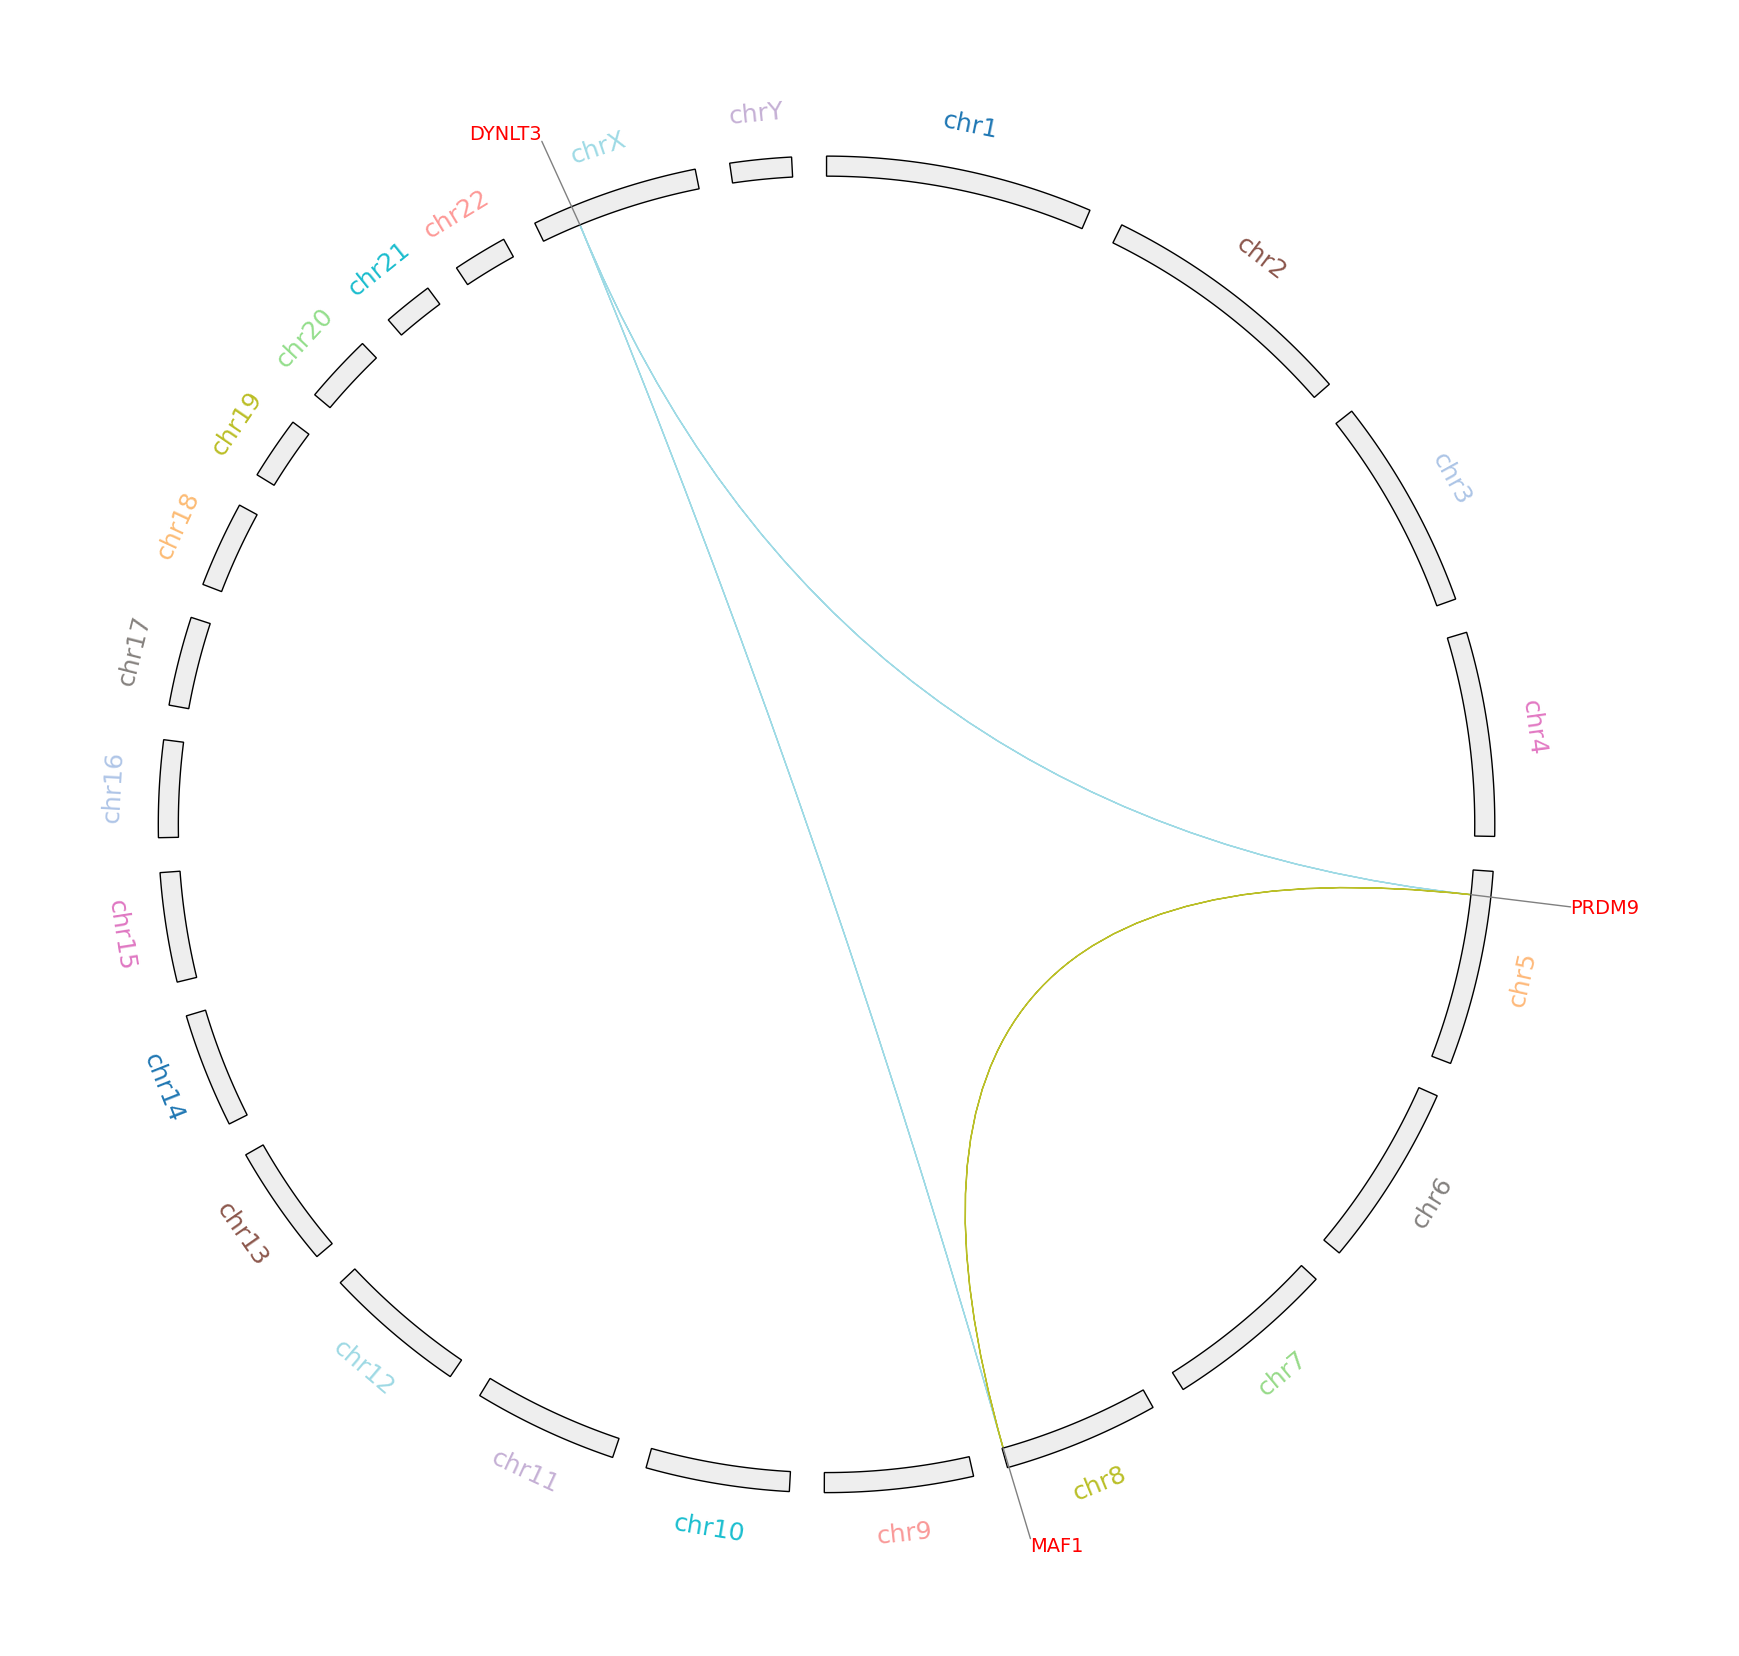

In [12]:
from pycirclize import Circos
from pycirclize.utils import ColorCycler, load_eukaryote_example_dataset
import numpy as np
from collections import defaultdict
import matplotlib
from matplotlib.colors import LinearSegmentedColormap
%config InlineBackend.figure_format = 'retina'

from geneinfo.coords import gene_coords
from functools import partial
gene_coords = partial(gene_coords, assembly='hg38')


chrom_lengths = {'hg19': {'chr1': 249250621, 'chr2': 243199373, 'chr3': 198022430, 'chr4': 191154276, 
                            'chr5': 180915260, 'chr6': 171115067, 'chr7': 159138663, 'chr8': 146364022, 
                            'chr9': 141213431, 'chr10': 135534747, 'chr11': 135006516, 'chr12': 133851895,
                            'chr13': 115169878, 'chr14': 107349540, 'chr15': 102531392, 'chr16': 90354753, 
                            'chr17': 81195210, 'chr18': 78077248, 'chr19': 59128983, 'chr20': 63025520, 
                            'chr21': 48129895, 'chr22': 51304566, 'chrX': 155270560, 'chrY': 59373566},
                    'hg38': {'chr1': 248956422, 'chr2': 242193529, 'chr3': 198295559, 'chr4': 190214555, 
                            'chr5': 181538259, 'chr6': 170805979, 'chr7': 159345973, 'chr8': 145138636, 
                            'chr9': 138394717, 'chr10': 133797422, 'chr11': 135086622, 'chr12': 133275309, 
                            'chr13': 114364328, 'chr14': 107043718, 'chr15': 101991189, 'chr16': 90338345, 
                            'chr17': 83257441, 'chr18': 80373285, 'chr19': 58617616, 'chr20': 64444167, 
                            'chr21': 46709983, 'chr22': 50818468, 'chrX': 156040895, 'chrY': 57227415}}   
                            

# TODO: make the centromeres fit each assembly!
centromeres = {
    'chr1':    (121700000, 125100000),
    'chr10':   (38000000, 41600000),
    'chr11':   (51000000, 55800000),
    'chr12':   (33200000, 37800000),
    'chr13':   (16500000, 18900000),
    'chr14':   (16100000, 18200000),
    'chr15':   (17500000, 20500000),
    'chr16':   (35300000, 38400000),
    'chr17':   (22700000, 27400000),
    'chr18':   (15400000, 21500000),
    'chr19':   (24200000, 28100000),
    'chr2':    (91800000, 96000000),
    'chr20':   (25700000, 30400000),
    'chr21':   (10900000, 13000000),
    'chr22':   (13700000, 17400000),
    'chr3':    (87800000, 94000000),
    'chr4':    (48200000, 51800000),
    'chr5':    (46100000, 51400000),
    'chr6':    (58500000, 62600000),
    'chr7':    (58100000, 62100000),
    'chr8':    (43200000, 47200000),
    'chr9':    (42200000, 45500000),
    'chrX':    (58100000, 63800000),
    'chrY':    (10300000, 10400000)} 

def register_shifted_cmap(cmap_name, n_lines=24):
    name_shifted = f'shifted_{cmap_name}'
    n = n_lines // 2
    cmap = matplotlib.colormaps[cmap_name]
    colors = cmap(np.linspace(0, 1, n))
    l = list(range(n))
    i = n//2
    colors = [colors[x] for y in zip(l, l[i:] + l[:i]) for x in y][:n_lines]
    _cmap = LinearSegmentedColormap.from_list(f'shifted_{cmap_name}', colors)
    try:
        matplotlib.colormaps.register(cmap=_cmap)
    except ValueError:
        # already registered, ignore
        pass
    return name_shifted
                      
def circos_plot(genes=[], links={}, cmap=None):

    ColorCycler.set_cmap(cmap)

    # chr_bed_file, cytoband_file, chr_links = load_eukaryote_example_dataset("hg38")
    # circos = Circos.initialize_from_bed(chr_bed_file, space=3, link_kws=dict(lw=10))
    
    circos = Circos(sectors=chrom_lengths['hg38'], space=3)


    chr_names = [s.name for s in circos.sectors]
    colors = ColorCycler.get_color_list(len(chr_names))
    chr_name2color = {name: color for name, color in zip(chr_names, colors)}

    gene_info = defaultdict(list)
    for chrom, start, end, label in gene_coords(genes):
        gene_info[chrom].append(((start+end)/2, label))

    for sector in circos.sectors:
        ideogram_base = 97
        ideogram_height = 3
        sector.text(sector.name, r=105, size=9, color=chr_name2color[sector.name])
        outer_track = sector.add_track((ideogram_base, ideogram_base+ideogram_height))
        outer_track.axis(fc="#eeeeee")

        pos_labels = gene_info.get(sector.name, [])
        for pos, label  in pos_labels:
            outer_track.annotate(pos, label, label_size=7, 
                                min_r=ideogram_base, 
                                max_r=ideogram_base+5*ideogram_height,
                                text_kws=dict(color='red')
                                )

    _from, _to = zip(*links)
    links = list(zip(gene_coords(_from), gene_coords(_to)))


    for a, b in links:
        _chrom = a[0]
        _from, _from_label = a[:3], a[3]
        _to, _to_label = b[:3], b[3]
        color = chr_name2color[_chrom]
        circos.link(_from, _to, color=color, 
                    lw=0.5, 
                    alpha=1,
                    zorder=0)

    figsize = (8, 8)

    # circos.savefig('circos_plot.pdf', figsize=figsize)
    fig = circos.plotfig(figsize=figsize)

cmap = register_shifted_cmap('tab20')
# cmap = 'tab10'

genes = ['DYNLT3', 'MAF1', 'PRDM9']

links = [('DYNLT3', 'MAF1'), ('DYNLT3', 'PRDM9'), ('MAF1', 'PRDM9')]

circos_plot(genes=genes, links=links, cmap=cmap)

In [13]:
# get_gene_info, get_all_groups, get_all_contexts,
# genes_by_context, genes_by_group, get_interactors,

get_gene_info('ADRA2C')

{'analysis_origin': {'analysis': 'Tishkoff_IBDmix_2026',
  'note': 'In candidate gene list from NHR analysis; 4p16.3 cluster with OTOP1/TMEM128',
  'source': 'IBDmix_NHR'},
 'chromosome': 'auto',
 'expression_contexts': ['neuron', 'adipocyte', 'kidney'],
 'gene_groups': ['cAMP/PKA module', 'IBDmix NHR candidates'],
 'notes': 'Best rescue candidate with PJA1: both modulate PKA R-subunit pool via independent mechanisms.',
 'references': [],
 'rescue_logic': 'rheostat'}

In [14]:
get_interactors('ADRA2C')

[{'gene': 'ADCY',
  'type': 'Inhibition',
  'context': 'cAMP/PKA module',
  'refs': ['PMID:10336518']}]

In [21]:
list(get_all_groups())

['Centriolar/manchette',
 'IBDmix NHR candidates',
 'IRS2/Akt module',
 'MT lattice/transport',
 'NF-kB signalling',
 'NMD/RNA processing',
 'Neurotrophin/endosome',
 'Phosphoinositide',
 'Siepel_ARGweaver-D_2020',
 'Xq27 miRNA cluster',
 'cAMP/PKA module',
 'gametologs']

In [22]:
genes_by_group('Siepel_ARGweaver-D_2020')

ADGRG4,DIAPH2-AS1,HS6ST2,MAGEA8-AS1,MIR891B,PRR32,SMPX
ATG4A,DMD,HS6ST2-AS1,MAOA,MIR892A,PSMD10,SRPX
BCLAF3,DYNLT3,IL1RAPL1,MAP7D2,MIR892B,RBMXL3,SYTL5
CACNA1F,EIF1AX,LANCL3,MBTPS2,MIR892C,RHOXF1,VSIG1
CCDC22,EIF1AX-AS1,LINC00850,MIR23C,MSL3,RHOXF1-AS1,XK
CD99L2,FAM47B,LINC01402,MIR4666B,MTM1,RHOXF1P1,YY2
CFAP47,FAM9B,LOC105373150,MIR548AJ2,MTMR1,RHOXF2B,
COL4A6,FLICR,LOC729609,MIR888,NLGN4X,RPS6KA3,
CYBB,FOXP3,LRCH2,MIR890,PAK3,SCARNA9L,
DIAPH2,FRMPD4,MAGEA8,MIR891A,PPP1R3F,SH3KBP1,


In [24]:
list(get_all_contexts())


['Dynein motor complex assembly',
 'GSK3β → tau → MT lattice',
 'HDAC6 → MT acetylation → motor preference',
 'IRS2/Akt → HDAC6 — X-linked effector, direct rescue candidate',
 'IRS2/PI3K/Akt module',
 'IRS2/PI3K/Akt → GSK3β → tau',
 'MAP7D3 / tau competition — indirect rescue candidate',
 'NF-κB module',
 'NF-κB module — not rescuable',
 'NMD pathway — not rescuable',
 'NMD pathway — sequential with XRN2',
 'Neurotrophin retrograde transport',
 'Spindle checkpoint',
 'TPTE/OCRL phosphoinositide triangle',
 'cAMP/PKA module',
 'cAMP/PKA module — X-linked',
 'cAMP/PKA module — rescue candidate',
 'cAMP/PKA module — structural',
 'cAMP/PKA → tau → MT lattice',
 'exploratory',
 'tau → MT occupancy competition']

In [ ]:
genes_by_context('Dynein motor complex assembly')

DYNC1H1,DYNC1I2,DYNC1LI1,DYNLT3


In [ ]:
#query_statements(gene=, stmt_type=, context=, hypothesis_only=)

NameError: name 'query_registry' is not defined

In [ ]:
#query_registry(gene=, group=, chromosome=, rescue_only=, analysis=)

In [ ]:
from gene_registry import load_registry, save_registry                                      
                                                                                            
reg = load_registry()                                                                       
reg['MAPT']['notes'] = 'Updated note'
del reg['SOME_GENE']  # remove an entry
save_registry(reg)

Statements:
stmts = load_store()        # returns INDRA Statement objects
for s in stmts:
    # modify evidence, agents, etc.
    s.evidence[0].annotations['context'] = 'new context'
stmts = [s for s in stmts if s.subj.name != 'REMOVE_ME']  # filter
save_store(stmts)